# Olist E-Commerce: Elite Business Intelligence Report

This notebook provides a professional analysis of the Olist e-commerce ecosystem, focusing on growth, customer behavior, and logistics. 

**Key Features:**
- Professional visuals with clear legends and annotations.
- Analysis of top performing products and categories with English translations.
- Simplified business recommendations for executive action.

In [68]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = 'bold'
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 10

def format_brl(x, pos): return f'R$ {x:,.0f}'
brl_formatter = FuncFormatter(format_brl)

# Portuguese to English Category Translation Map
category_map = {
    'cama_mesa_banho': 'Bed, Bath & Table',
    'beleza_saude': 'Health & Beauty',
    'esporte_lazer': 'Sports & Leisure',
    'moveis_decoracao': 'Furniture & Decor',
    'informatica_acessorios': 'Computers & Accessories',
    'utilidades_domesticas': 'Housewares',
    'relogios_presentes': 'Watches & Gifts',
    'telefonia': 'Telephony',
    'ferramentas_jardim': 'Garden Tools',
    'automotivo': 'Auto',
    'brinquedos': 'Toys',
    'perfumaria': 'Perfumery',
    'bebes': 'Babies',
    'papelaria': 'Stationery'
}

conn_str = "Driver={SQL Server};Server=.;Database=OlistDW;Trusted_Connection=yes;"
conn = pyodbc.connect(conn_str)
print("Connected successfully.")

Connected successfully.


## 1. Sales Trends: Revenue & Volume Over Time

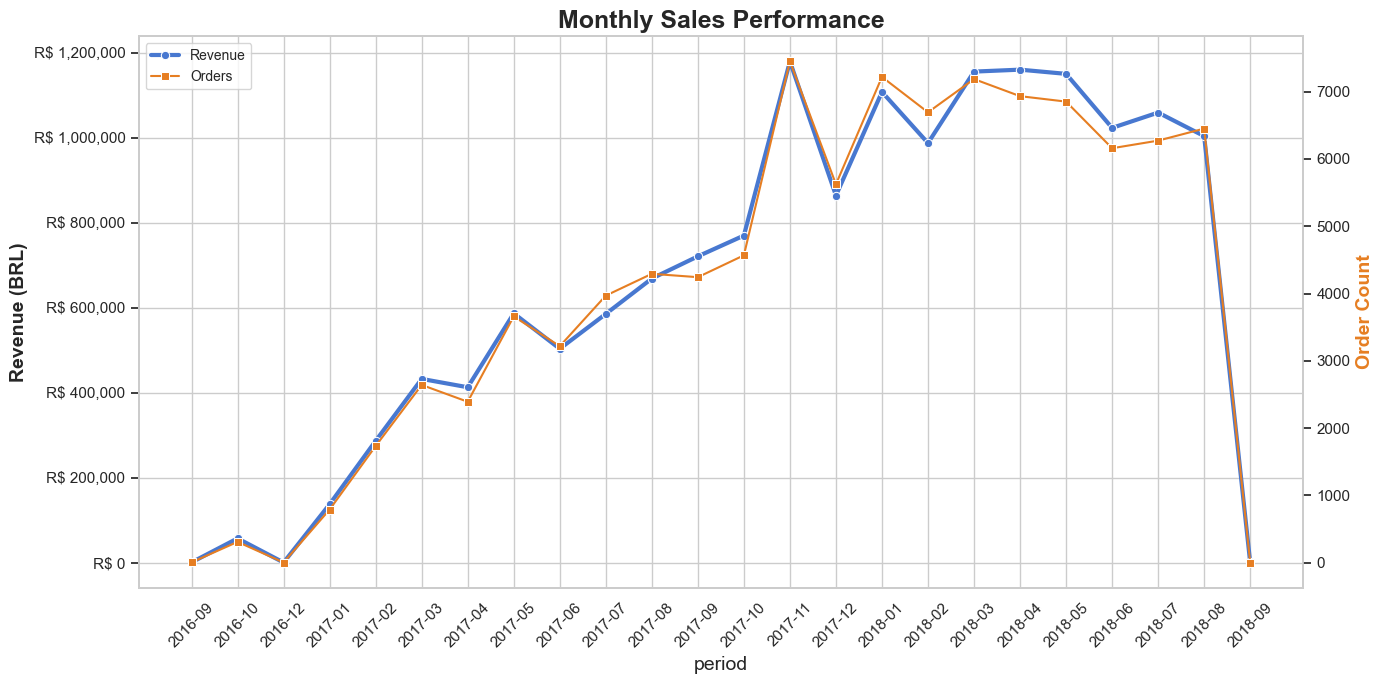

In [69]:
query = "SELECT d.year, d.month, SUM(f.total_value) as revenue, COUNT(DISTINCT f.order_id) as order_count FROM gold.fact_sales f JOIN gold.dim_date d ON f.key_date = d.key_date GROUP BY d.year, d.month ORDER BY d.year, d.month"
df = pd.read_sql(query, conn)
df['period'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots()
sns.lineplot(data=df, x='period', y='revenue', marker='o', linewidth=3, ax=ax1, label='Revenue')
ax1.set_ylabel('Revenue (BRL)', weight='bold')
ax1.yaxis.set_major_formatter(brl_formatter)

ax2 = ax1.twinx()
sns.lineplot(data=df, x='period', y='order_count', marker='s', color='#e67e22', ax=ax2, label='Orders')
ax2.set_ylabel('Order Count', weight='bold', color='#e67e22')
ax2.grid(False)
plt.title('Monthly Sales Performance')
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)
ax2.get_legend().remove()
plt.tight_layout()
plt.show()

## 2. Top Performers: Best Selling Categories & Products

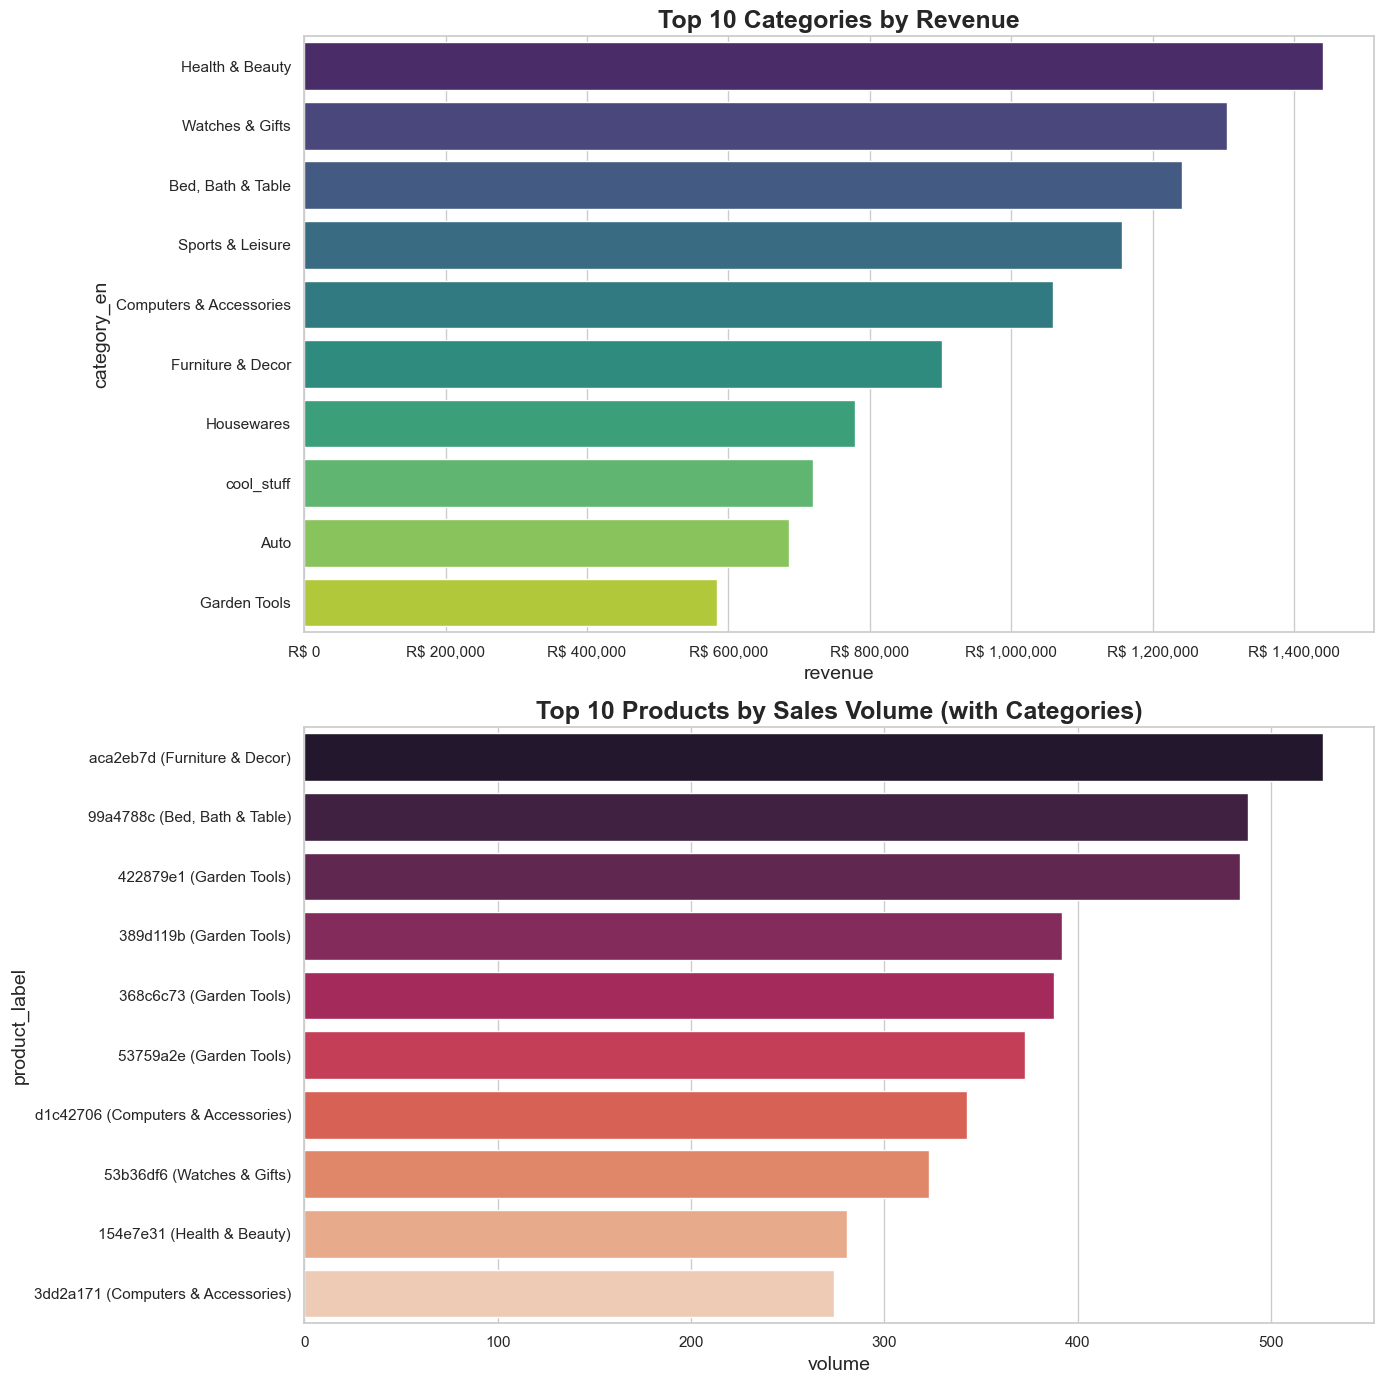

In [70]:
# Top 10 Categories
q_cat = "SELECT TOP 10 p.product_category_name, SUM(f.total_value) as revenue FROM gold.fact_sales f JOIN gold.dim_products p ON f.key_product = p.key_product WHERE p.product_category_name IS NOT NULL GROUP BY p.product_category_name ORDER BY revenue DESC"
df_cat = pd.read_sql(q_cat, conn)
df_cat['category_en'] = df_cat['product_category_name'].map(category_map).fillna(df_cat['product_category_name'])

# Top 10 Products with Categories
q_prod = "SELECT TOP 10 p.product_business_id, p.product_category_name, COUNT(*) as volume FROM gold.fact_sales f JOIN gold.dim_products p ON f.key_product = p.key_product GROUP BY p.product_business_id, p.product_category_name ORDER BY volume DESC"
df_prod = pd.read_sql(q_prod, conn)
df_prod['category_en'] = df_prod['product_category_name'].map(category_map).fillna(df_prod['product_category_name'])
df_prod['product_label'] = df_prod['product_business_id'].str[:8] + ' (' + df_prod['category_en'] + ')'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))
sns.barplot(data=df_cat, x='revenue', y='category_en', palette='viridis', ax=ax1)
ax1.set_title('Top 10 Categories by Revenue')
ax1.xaxis.set_major_formatter(brl_formatter)

sns.barplot(data=df_prod, x='volume', y='product_label', palette='rocket', ax=ax2)
ax2.set_title('Top 10 Products by Sales Volume (with Categories)')
plt.tight_layout()
plt.show()

## 3. Customer Retention

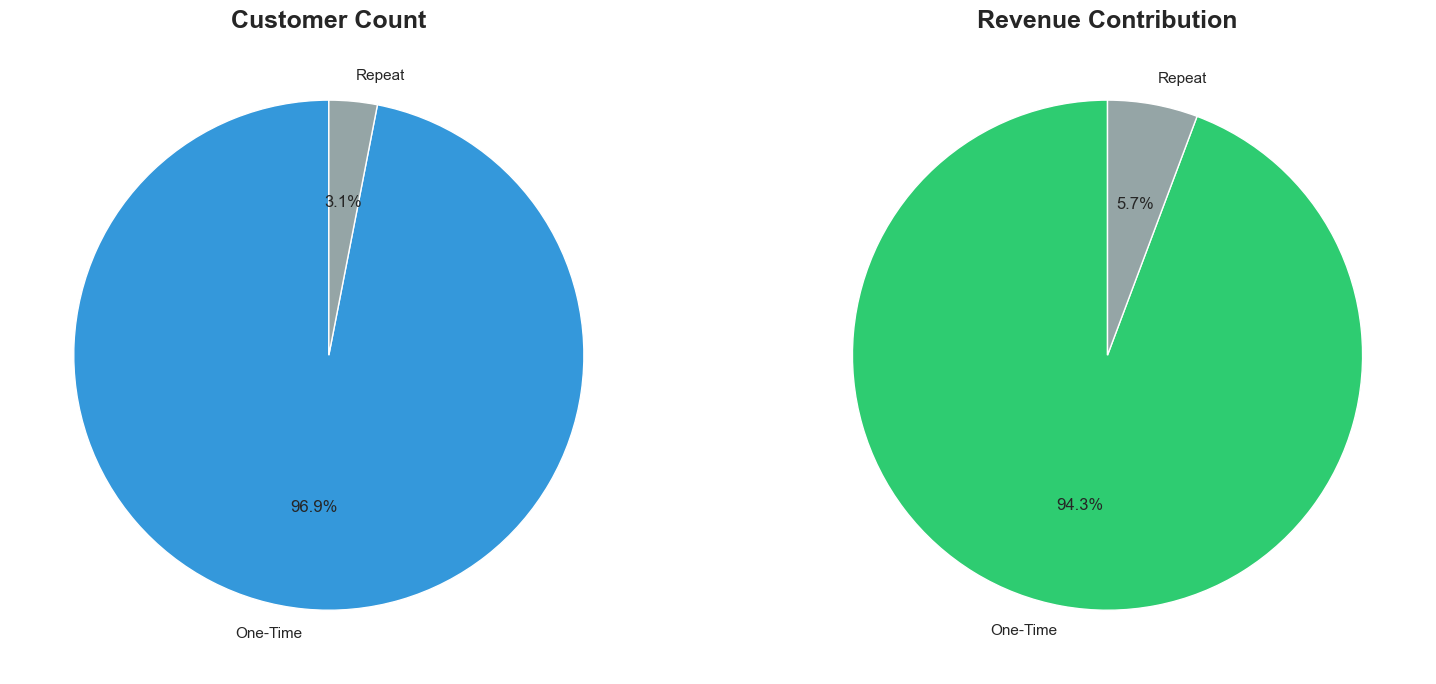

In [71]:
q_ret = "WITH CS AS (SELECT c.customer_unique_id, COUNT(DISTINCT f.order_id) as oc, SUM(f.total_value) as ts FROM gold.fact_sales f JOIN gold.dim_customers c ON f.key_customer = c.key_customer GROUP BY c.customer_unique_id) SELECT CASE WHEN oc > 1 THEN 'Repeat' ELSE 'One-Time' END as type, COUNT(*) as count, SUM(ts) as rev FROM CS GROUP BY CASE WHEN oc > 1 THEN 'Repeat' ELSE 'One-Time' END"
df_ret = pd.read_sql(q_ret, conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.pie(df_ret['count'], labels=df_ret['type'], autopct='%1.1f%%', colors=['#3498db', '#95a5a6'], startangle=90)
ax1.set_title('Customer Count')

ax2.pie(df_ret['rev'], labels=df_ret['type'], autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6'], startangle=90)
ax2.set_title('Revenue Contribution')
plt.tight_layout()
plt.show()

## 4. Payment Behavior

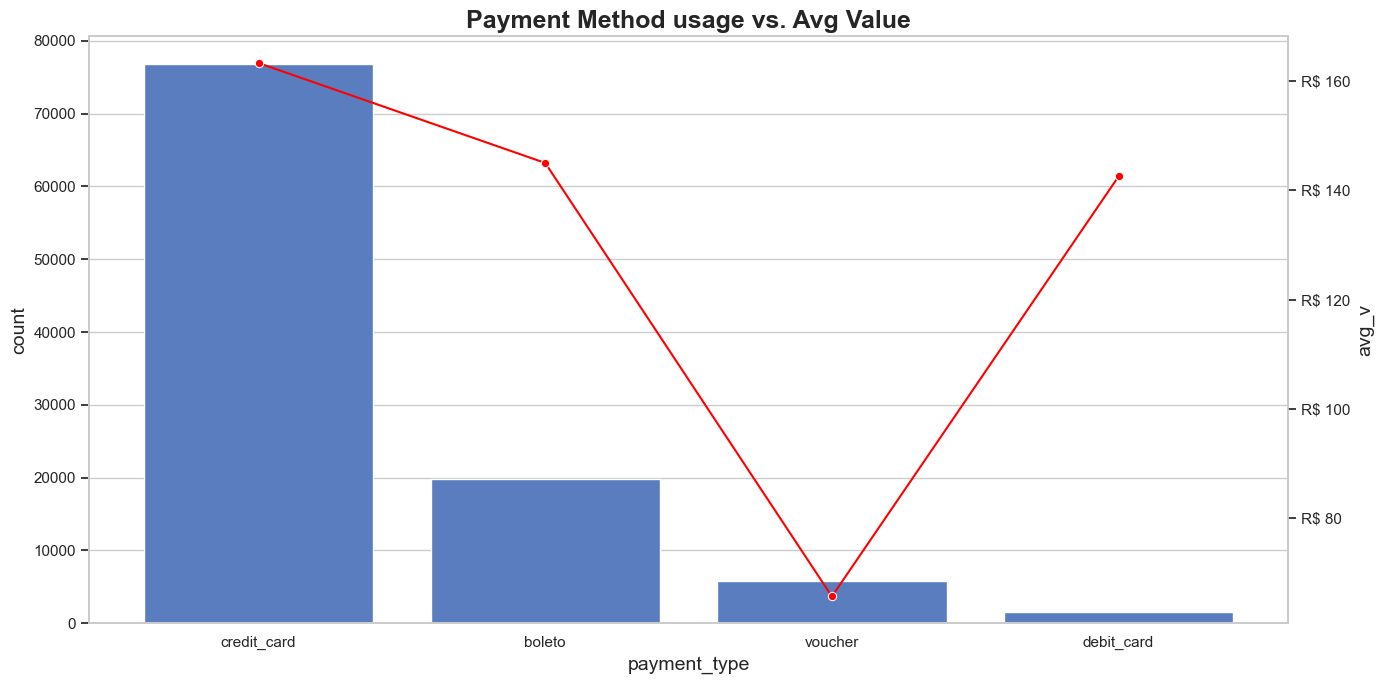

In [72]:
q_pay = "SELECT payment_type, COUNT(*) as count, AVG(payment_value) as avg_v FROM bronze.raw_order_payments WHERE payment_type != 'not_defined' GROUP BY payment_type ORDER BY count DESC"
df_pay = pd.read_sql(q_pay, conn)

fig, ax1 = plt.subplots()
sns.barplot(data=df_pay, x='payment_type', y='count', ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data=df_pay, x='payment_type', y='avg_v', marker='o', color='red', ax=ax2)
ax2.yaxis.set_major_formatter(brl_formatter)
ax2.grid(False)
plt.title('Payment Method usage vs. Avg Value')
plt.tight_layout()
plt.show()

## 5. Peak Hours & Logistics

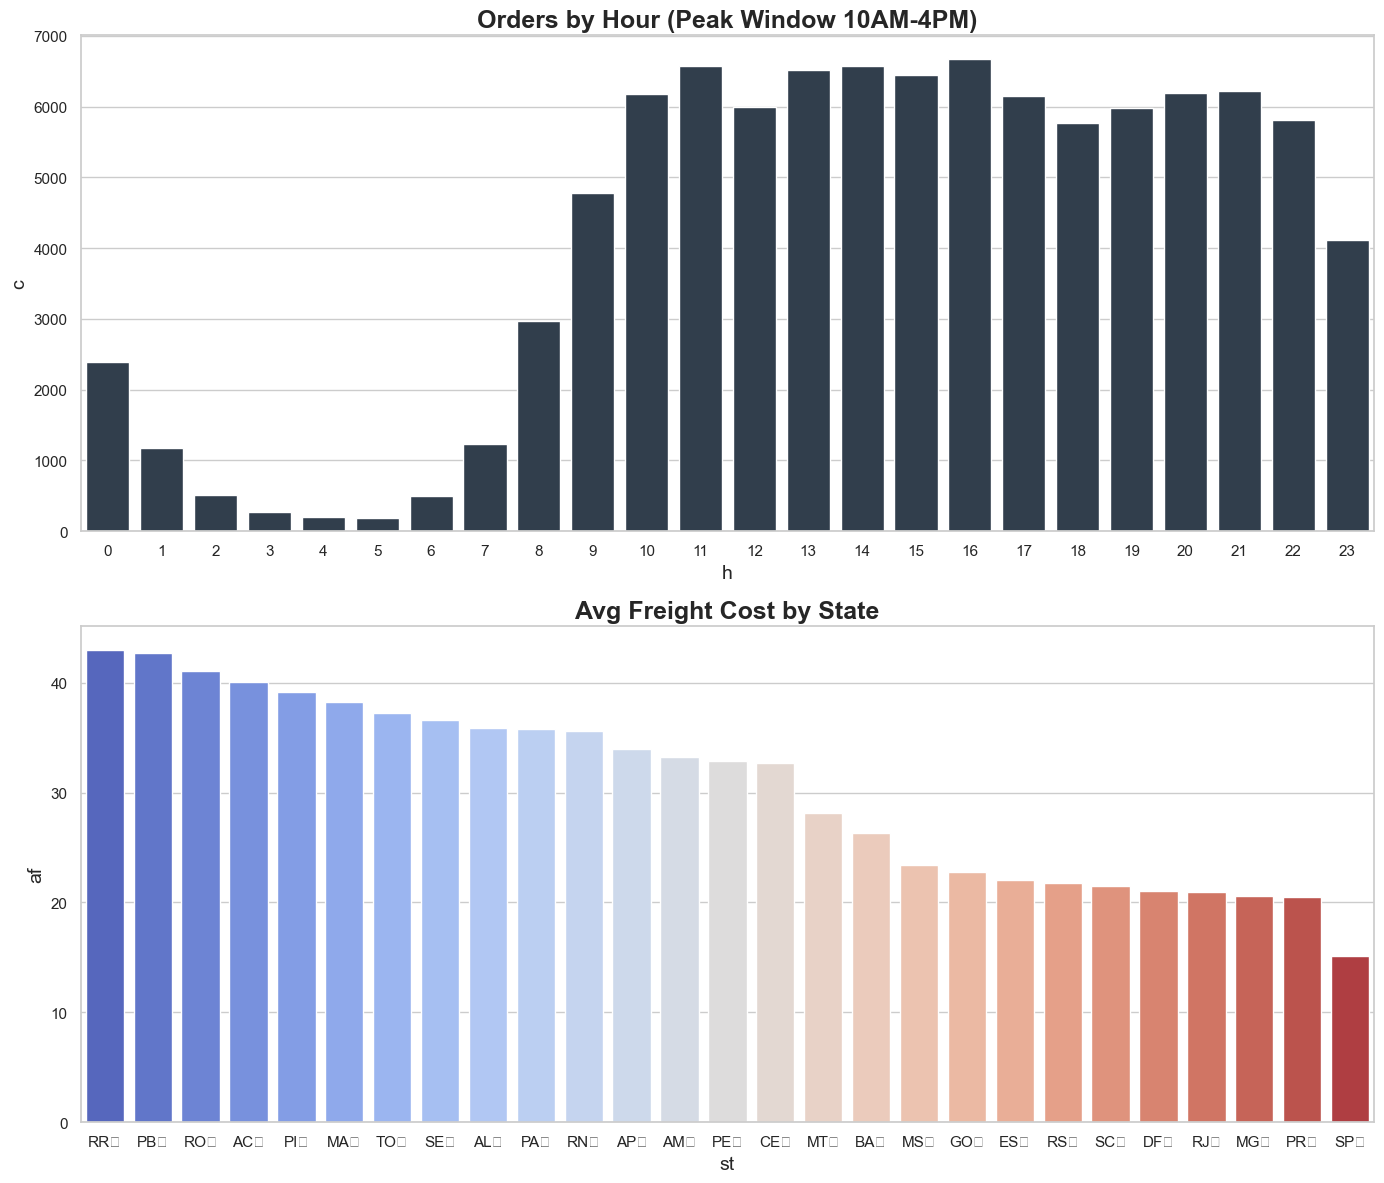

In [73]:
q_h = "SELECT DATEPART(HOUR, order_purchase_timestamp) as h, COUNT(*) as c FROM bronze.raw_orders GROUP BY DATEPART(HOUR, order_purchase_timestamp) ORDER BY h"
df_h = pd.read_sql(q_h, conn)

q_f = "SELECT c.customer_state as st, AVG(f.freight_value) as af FROM gold.fact_sales f JOIN gold.dim_customers c ON f.key_customer = c.key_customer GROUP BY c.customer_state ORDER BY af DESC"
df_f = pd.read_sql(q_f, conn)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
sns.barplot(data=df_h, x='h', y='c', color='#2c3e50', ax=ax1)
ax1.set_title('Orders by Hour (Peak Window 10AM-4PM)')

sns.barplot(data=df_f, x='st', y='af', palette='coolwarm', ax=ax2)
ax2.set_title('Avg Freight Cost by State')
plt.tight_layout()
plt.show()

## 6. Business Insights & Recommendations

### 1. Repeat Customers are Key
- **What we see:** Only 3% of customers come back, but they spend more per order.
- **Action:** Create a simple loyalty program (e.g., a discount on the 2nd order) to keep people coming back.

### 2. Credit Cards Drive Big Sales
- **What we see:** Most people pay with credit cards, and these are usually the largest orders.
- **Action:** Highlight "Buy Now, Pay Later" options for expensive items like Watches or Electronics.

### 3. High Shipping Costs in Remote Areas
- **What we see:** Some states (like RR or AP) have very high delivery fees, which likely stops people from buying.
- **Action:** Look for local delivery partners in those specific states to lower the cost for customers.

### 4. Market During Peak Hours
- **What we see:** Most sales happen between **10:00 AM and 4:00 PM**.
- **Action:** Send your marketing emails and phone notifications at 9:30 AM to catch people just as they start shopping.

### 5. Focus on Top Categories
- **What we see:** Health & Beauty and Bed/Bath/Table (Cama, Mesa e Banho) are the biggest money-makers.
- **Action:** Make sure these items are always in stock and easy to find on the homepage.

In [74]:
conn.close()
print("Analysis finalized.")

Analysis finalized.
